# Figures 2 & 3: Relationship Between Dendritic and Somatic Spikes

This notebook analyzes simulations from [Headley et al. (eLife, 2026): "Spatially targeted inhibitory rhythms differentially affect neuronal integration"](https://doi.org/10.7554/eLife.95562).

## Background
Dendritic spikes induced by synaptic activity are the principal drivers of somatic action potentials. Layer 5 pyramidal neurons have a substantially longer apical trunk, which increases the electrotonic distance of their apical tuft from the soma and diminishes the ability of tuft synapses to elicit action potentials. Voltage-gated Ca²⁺ channels at the apical nexus compensate for this by producing a robust Ca²⁺ spike that drives a burst of action potentials at the soma.

## Analysis Overview
This notebook computes spike-triggered averages (STAs) between somatic action potentials and dendritic spikes, stratified by:
1. **Electrotonic distance** of the dendritic segment from the soma (binned into deciles)
2. **Dendritic branch type**: apical vs. basal
3. **Dendritic spike type**: Na⁺, NMDA, and Ca²⁺ spikes

## Key Findings from the Paper
- **Na⁺ spikes** increased 2-3 ms prior to somatic APs, strongest in compartments nearest the soma (300% increase in apical trunk)
- **NMDA spikes** increased ~25 ms prior to somatic APs, with stronger coupling in apical vs. basal branches
- **Ca²⁺ spikes** at the apical nexus increased within 20 ms of somatic APs and serve as a thresholded nonlinearity for NMDA spikes in the apical tuft to drive action potentials

In [23]:

import sys
sys.path.append('..') # have to do this for relative imports in jupyter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.sta_files import sta_files
from src.load_caspks_csv import load_caspks_csv
from src.load_spike_h5 import load_spike_h5

# 1.0 Analysis Parameters

Parameters for computing spike-triggered averages (STAs). For each dendritic compartment, a binary time series with 2 ms bins indicates whether a dendritic spike was present. The STA is computed around somatic action potential times, and percent change from the simulation mean is calculated. STAs are grouped by electrotonic distance percentile (10% bins) from the soma and dendritic type (apical or basal).

In [24]:
samps_per_ms = 10 
sim_win = [0, 2000000] # beginning and start points of simulation in samples
sta_win = [-100, 100] # multiply by step to get window in milliseconds
sta_step = 1 # binning step for each point in the STA
step = 2 * samps_per_ms # number of simulation steps for creating the dendritic 
                        # event occurrence series

## 1.1 Simulation Files

Simulation with Poisson excitation and inhibition (no rhythmic modulation). This serves as the baseline condition to characterize the intrinsic relationship between dendritic spikes and action potentials under naturalistic synaptic drive. The model produces a median firing rate of ~5.3 Hz, consistent with in vivo cortical rates.

In [25]:
# locate simulation files
root_dir = 'D:\\DendCompOscPublic\\output_allpoisson\\'
sim_dict = {'SimName': 'output_allpoisson',
            'RootDir': root_dir,
            'CaFile': root_dir + 'output_allpoisson_ca_nex.csv',
            'NaFile': root_dir + 'output_allpoisson_na_nex.csv',
            'NMDAFile': root_dir + 'output_allpoisson_nmda_nex.csv',
            'APFile': root_dir + 'spikes.h5'}

sim_dict


{'SimName': 'output_allpoisson',
 'RootDir': 'D:\\DendCompOscPublic\\output_allpoisson\\',
 'CaFile': 'D:\\DendCompOscPublic\\output_allpoisson\\output_allpoisson_ca_nex.csv',
 'NaFile': 'D:\\DendCompOscPublic\\output_allpoisson\\output_allpoisson_na_nex.csv',
 'NMDAFile': 'D:\\DendCompOscPublic\\output_allpoisson\\output_allpoisson_nmda_nex.csv',
 'APFile': 'D:\\DendCompOscPublic\\output_allpoisson\\spikes.h5'}

# 2.0 Spike-Triggered Averages: Dendritic Spikes → Action Potentials

Compute STAs for Na⁺, NMDA, and Ca²⁺ dendritic spikes centered on somatic action potentials (Figure 2 in the paper).

**Expected results:**
- **Na⁺ spikes**: Rapid regenerative events (<1 ms) that increase immediately (2-3 ms) prior to APs. Strongest coupling in compartments electrotonically close to the soma.
- **NMDA spikes**: Longer events (20-80 ms) that increase ~25 ms prior to APs. Apical branches show stronger coupling than basal branches.
- **Ca²⁺ spikes**: Generated at the apical nexus, increase within 20 ms of APs. NMDA spikes in the apical tuft can drive APs indirectly by triggering Ca²⁺ spikes.

In [26]:
# process the simulation
pois_sta = {}
pois_sta['ca_sta'] = sta_files(sim_dict['CaFile'], sim_dict['APFile'], 
                               step, sim_win,sta_step,sta_win, agg_colname='Elec_distanceQ')
pois_sta['nmda_sta'] = sta_files(sim_dict['NMDAFile'], sim_dict['APFile'], 
                                 step, sim_win,sta_step,sta_win, agg_colname='Elec_distanceQ')
pois_sta['na_sta'] = sta_files(sim_dict['NaFile'], sim_dict['APFile'], 
                               step, sim_win,sta_step,sta_win, agg_colname='Elec_distanceQ')

pois_sta['ca_a'] = pois_sta['ca_sta'].loc['apic','sta']
pois_sta['nmda_a'] = pois_sta['nmda_sta'].loc['apic','sta']
pois_sta['nmda_b'] = pois_sta['nmda_sta'].loc['dend','sta']
pois_sta['na_a'] = pois_sta['na_sta'].loc['apic','sta']
pois_sta['na_b'] = pois_sta['na_sta'].loc['dend','sta']


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\scipy\stats\_axis_nan_policy.py:527: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


## 2.1 Visualization: Percent Change in Dendritic Spike Incidence Around APs

Heatmaps show percent change in dendritic spike presence relative to the simulation mean, stratified by electrotonic distance (y-axis, 90th percentile at top = most distal) and time from action potential (x-axis).

**Interpretation:**
- Red colors indicate increased dendritic spike incidence relative to baseline
- Blue colors indicate decreased incidence
- The timing and magnitude of peaks reveal the temporal coupling between dendritic and somatic events

In [27]:
t_list = np.arange(sta_win[0], sta_win[1], sta_step) * (step / samps_per_ms)
eqt_list = np.arange(9,-1,-1)

t_inds = np.where(np.abs(t_list)<=50)[0]
eqt_inds = np.arange(0,10)#np.where(eqt_list>0)[0]

def plot_sta_im(data_arr,ax,**kwargs):

    # Plot the data array as an image
    ax_im = ax.imshow(data_arr[eqt_inds[0]:eqt_inds[-2],t_inds[0]:t_inds[-1]], 
                      extent=[t_list[t_inds[0]], t_list[t_inds[-1]],
                              eqt_list[eqt_inds[0]], eqt_list[eqt_inds[-2]]],
                      interpolation='none',
                      cmap='coolwarm',
                      norm=colors.CenteredNorm(vcenter=0), 
                      **kwargs)
    
    # Plot the color bar
    plt.colorbar(ax_im,ax=ax)
    
    # Plot the vertical axis
    ax.axvline(0,color='white',linestyle=':')
    
    # Set the aspect ratio of the plot
    ax.set_aspect('auto')

def plot_sta_stair(data_arr,ax):
    mean_data = np.mean(data_arr[eqt_inds[0]:eqt_inds[-1],t_inds[0]:t_inds[-1]],0)

    ax_im = ax.stairs(mean_data, np.hstack((t_list[t_inds[:-1]], t_list[t_inds[-1]])),
                     fill=True, baseline=0)
    
    ax.axvline(0,color='black',linestyle=':')
    ax.set_aspect('auto')

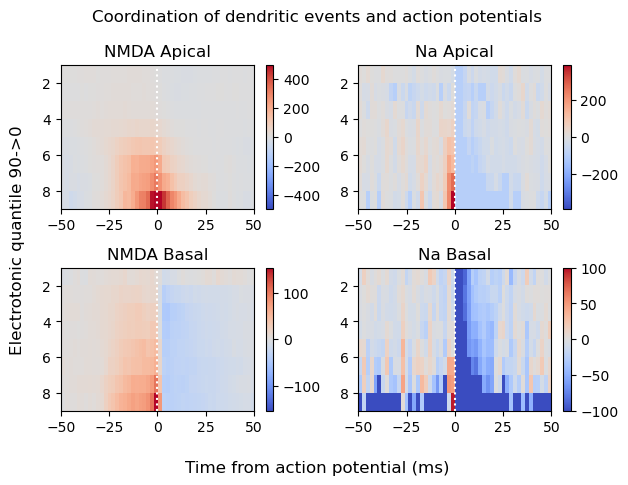

In [28]:
fig,ax = plt.subplots(2,2)
plot_sta_im(pois_sta['nmda_a'], ax[0,0])
ax[0,0].set_title('NMDA Apical')
plot_sta_im(pois_sta['nmda_b'], ax[1,0])
ax[1,0].set_title('NMDA Basal')
plot_sta_im(pois_sta['na_a'], ax[0,1])
ax[0,1].set_title('Na Apical')
plot_sta_im(pois_sta['na_b'], ax[1,1])
ax[1,1].set_title('Na Basal')
fig.supxlabel('Time from action potential (ms)')
fig.supylabel('Electrotonic quantile 90->0')
fig.suptitle('Coordination of dendritic events and action potentials')
fig.tight_layout()


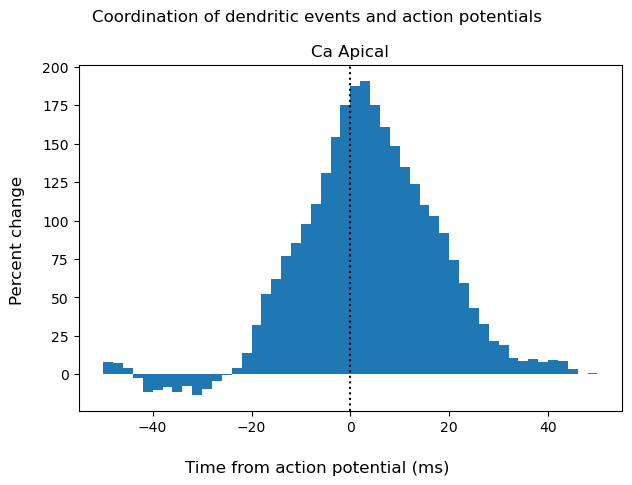

In [29]:
fig,ax = plt.subplots()
plot_sta_stair(pois_sta['ca_a'],ax)
ax.set_title('Ca Apical')
fig.supxlabel('Time from action potential (ms)')
fig.supylabel('Percent change')
fig.suptitle('Coordination of dendritic events and action potentials')
fig.tight_layout()


# 3.0 Ca²⁺ Spikes as a Second Integrative Mechanism (Figure 3)

Compute STAs centered on Ca²⁺ spike initiation to examine how NMDA spikes in the apical dendrites relate to Ca²⁺ spike generation.

**Background from the paper:**
- Ca²⁺ spikes originate at the apical nexus where the trunk branches into the tuft
- This region is electrotonically close to the entire apical trunk, facilitating Ca²⁺ spike propagation
- NMDA spikes in the apical tuft normally have weak direct coupling with somatic spiking but may elicit APs indirectly by driving Ca²⁺ spikes
- The apical nexus serves as a "thresholded nonlinearity" for distal inputs to drive somatic output

In [30]:
# process the simulation
pois_ca_sta = {}
pois_ca_sta['nmda_sta'] = sta_files(sim_dict['NMDAFile'], sim_dict['CaFile'], 
                                 step, sim_win,sta_step,sta_win, 
                                 agg_colname='Elec_distance_nexusQ', ca_spk=True)
pois_ca_sta['na_sta'] = sta_files(sim_dict['NaFile'], sim_dict['CaFile'], 
                               step, sim_win,sta_step,sta_win, 
                               agg_colname='Elec_distance_nexusQ', ca_spk=True)

pois_ca_sta['nmda_a'] = pois_ca_sta['nmda_sta'].loc['apic','sta']
pois_ca_sta['na_a'] = pois_ca_sta['na_sta'].loc['apic','sta']


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_caspks_csv.py:30: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  caspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_caspks_csv.py:30: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  caspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\scipy\stats\_axis_nan_policy.py:527: RuntimeWarning: Precisio

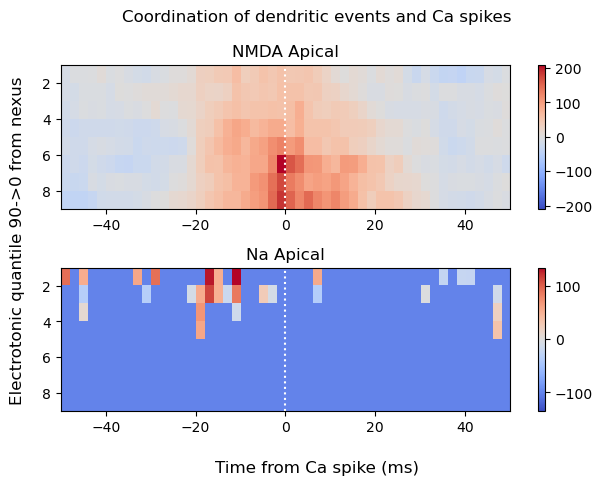

In [31]:
fig,ax = plt.subplots(2,1)
plot_sta_im(pois_ca_sta['nmda_a'], ax[0])
ax[0].set_title('NMDA Apical')
plot_sta_im(pois_ca_sta['na_a'], ax[1])
ax[1].set_title('Na Apical')

fig.supxlabel('Time from Ca spike (ms)')
fig.supylabel('Electrotonic quantile 90->0 from nexus')
fig.suptitle('Coordination of dendritic events and Ca spikes')
fig.tight_layout()

## 3.1 Enhanced NMDA-AP Coupling During Ca²⁺ Spikes (Figure 3D)

This analysis tests whether Ca²⁺ spikes change the spike-triggered average between apical tuft NMDA spikes and action potentials.

**Approach:**
- Select APs that occur within 20 ms after a Ca²⁺ spike
- Compute the STA between NMDA spikes and these Ca²⁺-associated APs
- Compare with the baseline STA computed for all APs

**Expected result from paper (Figure 3D):**
- APs preceded by a Ca²⁺ spike show **increased coupling** with apical NMDA spikes
- Basal dendrites show no such change, confirming this is specific to the apical integrative mechanism

In [32]:
# get spkikes that are 20 ms after the start of a Ca spike
caspk_t = load_caspks_csv(sim_dict['CaFile'])
spk_t = load_spike_h5(sim_dict['APFile'])

lag_win = samps_per_ms * 20
spk_ca_t = [curr_spk for curr_spk in spk_t if np.any(((curr_spk-caspk_t)<lag_win)&((curr_spk-caspk_t)>=0))]

c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_caspks_csv.py:30: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  caspk_df = pd.read_csv(fpath)


In [33]:
# process the simulation
pois_canmda_sta = {}
pois_canmda_sta['nmda_sta'] = sta_files(sim_dict['NMDAFile'], spk_ca_t, 
                                 step, sim_win,sta_step,sta_win, 
                                 agg_colname='Elec_distanceQ')
pois_canmda_sta['na_sta'] = sta_files(sim_dict['NaFile'], spk_ca_t, 
                                 step, sim_win,sta_step,sta_win, 
                                 agg_colname='Elec_distanceQ')

pois_canmda_sta['nmda_a'] = pois_canmda_sta['nmda_sta'].loc['apic','sta']
pois_canmda_sta['nmda_b'] = pois_canmda_sta['nmda_sta'].loc['dend','sta']
pois_canmda_sta['na_a'] = pois_canmda_sta['na_sta'].loc['apic','sta']
pois_canmda_sta['na_b'] = pois_canmda_sta['na_sta'].loc['dend','sta']


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\scipy\stats\_axis_nan_policy.py:527: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\scipy\stats\_axis_nan_policy.py:527: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Resul

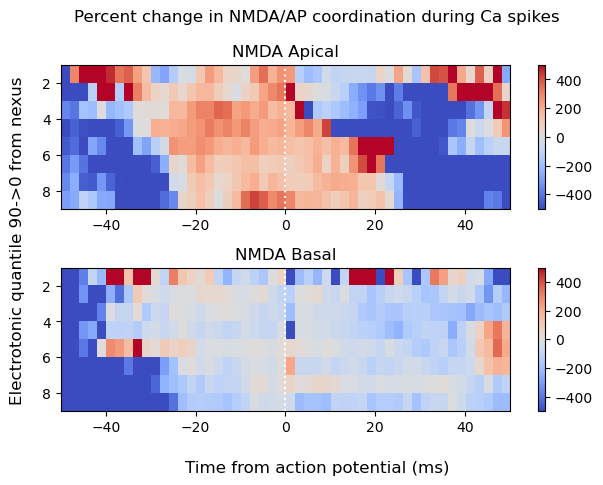

In [34]:
# numpy restrict values to set range
def prc_chg(chg_map,base_map):
    # set denom values less than 10 to nan
    
    #base_map[abs(base_map)<10] = np.nan
    #out_map = np.clip(chg_map/base_map,-5,5)
    out_map = np.clip((chg_map-base_map)/np.abs(base_map), -5, 5)*100

    
    return out_map

fig,ax = plt.subplots(2,1)
plot_sta_im(prc_chg(pois_canmda_sta['nmda_a'],pois_sta['nmda_a']), ax[0])
ax[0].set_title('NMDA Apical')
plot_sta_im(prc_chg(pois_canmda_sta['nmda_b'],pois_sta['nmda_b']), ax[1])
ax[1].set_title('NMDA Basal')
fig.supxlabel('Time from action potential (ms)')
fig.supylabel('Electrotonic quantile 90->0 from nexus')
fig.suptitle('Percent change in NMDA/AP coordination during Ca spikes')
fig.tight_layout()
